# 05 — Synthesis: What This Means

Three findings, one framework for thinking about AI and work.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import build_task_feature_matrix, load_onet_skills
from src.features import (
    build_feature_matrix, compute_within_occupation_heterogeneity,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
C = {'auto': '#E63946', 'aug': '#457B9D', 'accent': '#F4A261', 'teal': '#2A9D8F'}

In [2]:
tasks = build_task_feature_matrix()
tu = tasks.drop_duplicates(subset='task_name').reset_index(drop=True)
occ_features = build_feature_matrix()

## The occupation group landscape

Aggregating task-level metrics by occupation group reveals which fields
are most affected — and in which direction.

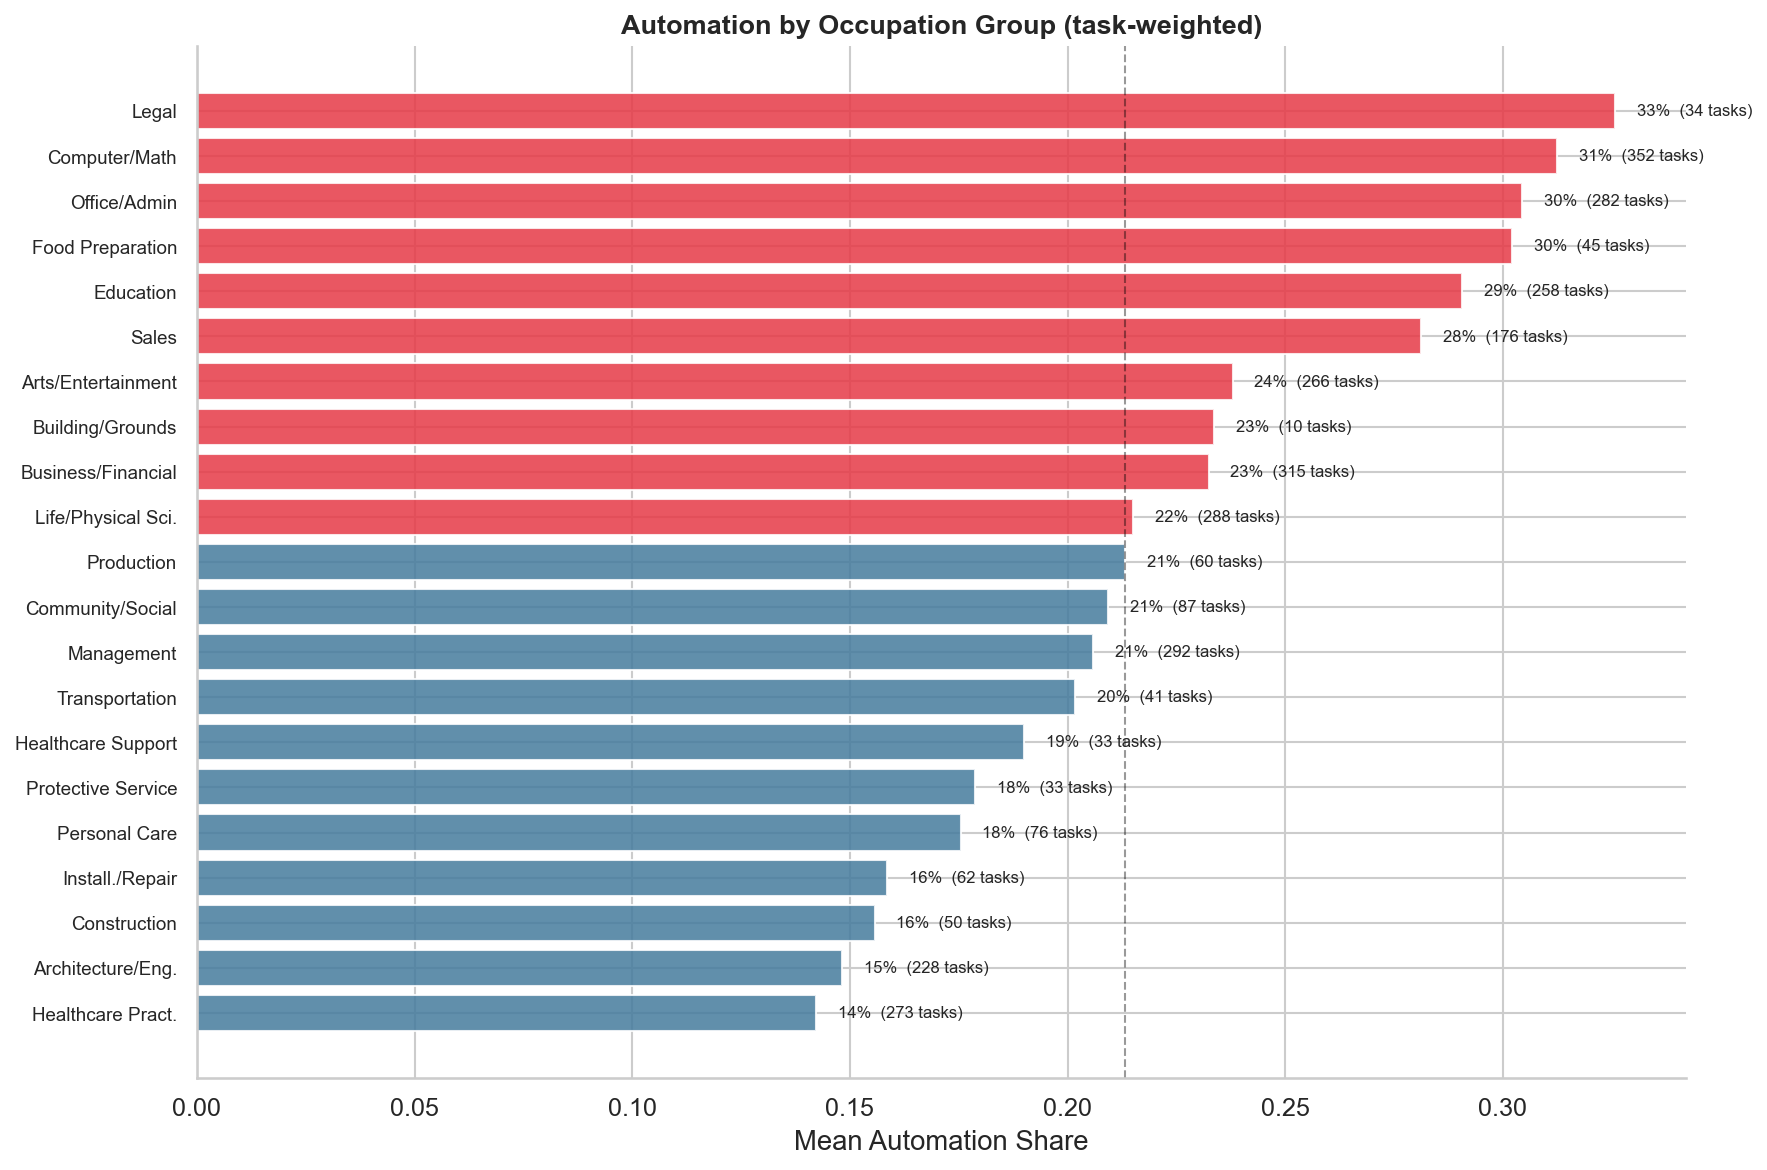

In [3]:
major_group_names = {
    '11': 'Management', '13': 'Business/Financial', '15': 'Computer/Math',
    '17': 'Architecture/Eng.', '19': 'Life/Physical Sci.',
    '21': 'Community/Social', '23': 'Legal', '25': 'Education',
    '27': 'Arts/Entertainment', '29': 'Healthcare Pract.',
    '31': 'Healthcare Support', '33': 'Protective Service',
    '35': 'Food Preparation', '37': 'Building/Grounds',
    '39': 'Personal Care', '41': 'Sales', '43': 'Office/Admin',
    '45': 'Farming/Fishing', '47': 'Construction', '49': 'Install./Repair',
    '51': 'Production', '53': 'Transportation',
}
tasks['group_name'] = tasks['soc_code'].astype(str).str[:2].map(major_group_names)

gs = (
    tasks.dropna(subset=['group_name'])
    .groupby('group_name')
    .agg(
        mean_auto=('automation_share', 'mean'),
        mean_autonomy=('ai_autonomy_mean', 'mean'),
        mean_sc=('skill_compression', 'mean'),
        n_tasks=('task_name', 'nunique'),
    )
    .dropna().query('n_tasks >= 10')
    .sort_values('mean_auto', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 8))
colors = [C['auto'] if v > gs['mean_auto'].median() else C['aug'] for v in gs['mean_auto']]
ax.barh(range(len(gs)), gs['mean_auto'], color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(gs)))
ax.set_yticklabels(gs.index, fontsize=9)

for i, (_, row) in enumerate(gs.iterrows()):
    ax.text(row['mean_auto'] + 0.005, i,
            f"{row['mean_auto']:.0%}  ({row['n_tasks']:.0f} tasks)",
            va='center', fontsize=8)

ax.axvline(gs['mean_auto'].median(), color='black', linestyle='--', linewidth=1, alpha=0.4)
ax.set_xlabel('Mean Automation Share')
ax.set_title('Automation by Occupation Group (task-weighted)',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/13_automation_by_group.png', bbox_inches='tight')
plt.show()

## The three findings in one visualization

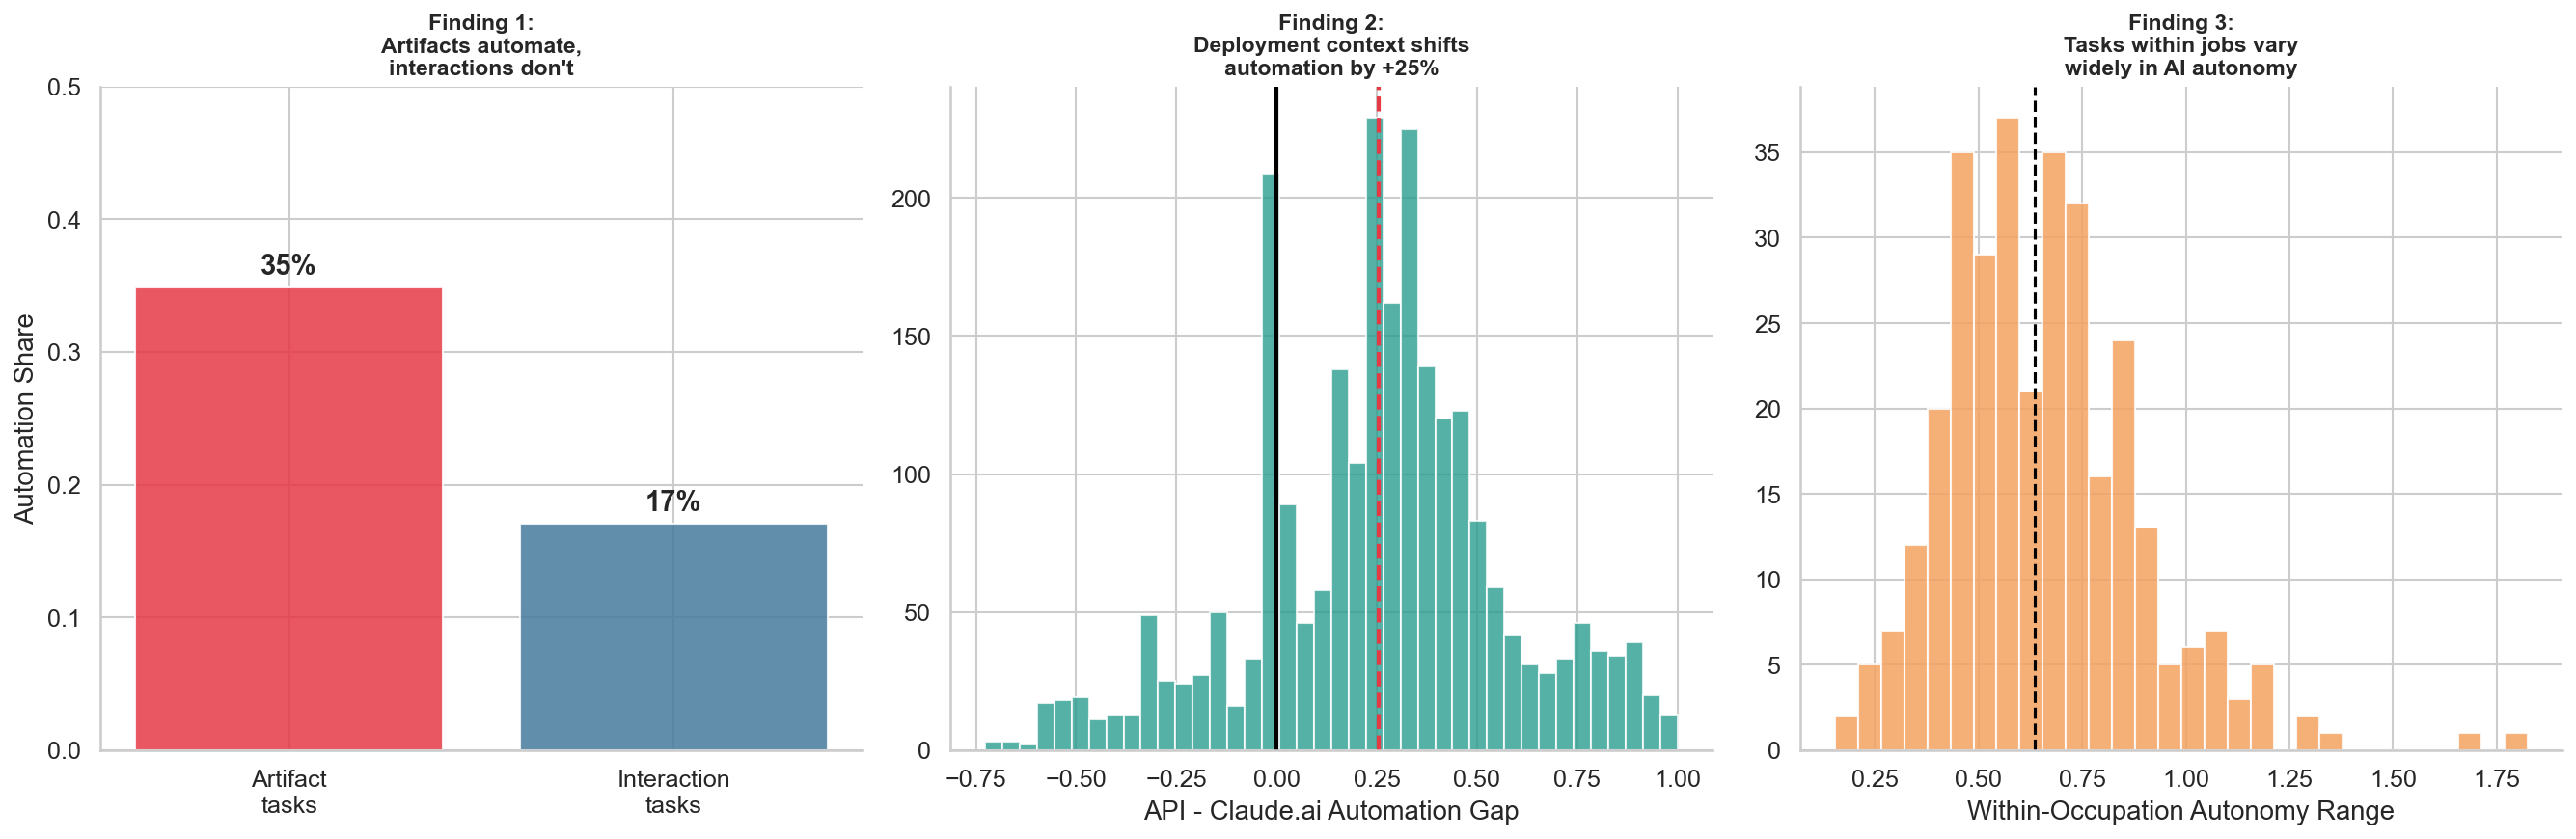

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Finding 1: Artifact vs Interaction
ax = axes[0]
reliable = tu[tu['conversation_count'] >= 20].copy()
reliable['first_verb'] = reliable['task_name'].str.lower().str.split().str[0]
produce = ['write', 'prepare', 'draft', 'create', 'compile', 'compose', 'generate', 'produce',
           'calculate', 'compute', 'transcribe', 'record', 'convert']
interact = ['advise', 'counsel', 'teach', 'explain', 'confer', 'consult', 'negotiate',
            'interview', 'communicate', 'collaborate', 'educate', 'mentor', 'present']
p_val = reliable[reliable['first_verb'].isin(produce)]['automation_share'].mean()
i_val = reliable[reliable['first_verb'].isin(interact)]['automation_share'].mean()
ax.bar(['Artifact\ntasks', 'Interaction\ntasks'], [p_val, i_val],
       color=[C['auto'], C['aug']], alpha=0.85, edgecolor='white')
ax.set_ylabel('Automation Share')
ax.set_title('Finding 1:\nArtifacts automate,\ninteractions don\'t', fontweight='bold', fontsize=11)
for i, v in enumerate([p_val, i_val]):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontweight='bold', fontsize=14)
ax.set_ylim(0, 0.5)

# Finding 2: Platform determines automation
ax = axes[1]
from src.features import compute_platform_gap
gap = compute_platform_gap()
ax.hist(gap['automation_gap'], bins=40, color=C['teal'], alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=2)
ax.axvline(gap['automation_gap'].mean(), color=C['auto'], linestyle='--', linewidth=2)
ax.set_xlabel('API - Claude.ai Automation Gap')
ax.set_title(f'Finding 2:\nDeployment context shifts\nautomation by +{gap["automation_gap"].mean():.0%}',
             fontweight='bold', fontsize=11)

# Finding 3: Tasks, not jobs
ax = axes[2]
het = compute_within_occupation_heterogeneity(tasks)
het_r = het[het['n_tasks'] >= 5]
ax.hist(het_r['autonomy_range'], bins=30, color=C['accent'], alpha=0.85, edgecolor='white')
ax.set_xlabel('Within-Occupation Autonomy Range')
ax.set_title(f'Finding 3:\nTasks within jobs vary\nwidely in AI autonomy', fontweight='bold', fontsize=11)
ax.axvline(het_r['autonomy_range'].median(), color='black', linestyle='--', linewidth=1.5)

sns.despine()
plt.tight_layout()
plt.savefig('../figures/14_three_findings.png', bbox_inches='tight')
plt.show()

## Summary

In [5]:
print('The Jagged Adoption Frontier')
print('=' * 60)
print(f'Data:  {len(tu):,} tasks across {tasks["soc_code"].nunique()} occupations')
print(f'       4 Anthropic Economic Index releases (Mar 2025 - Mar 2026)')
print(f'       O*NET skills database (35 skills per occupation)')
print()
print('FINDING 1: AI automates artifacts, augments interactions')
print(f'  Artifact tasks (write, compute, create): ~35% automated')
print(f'  Interaction tasks (advise, teach, consult): ~17% automated')
print(f'  Education level has NO predictive power for automation')
print(f'  -> The divide is about output type, not skill level')
print()
print('FINDING 2: Deployment context determines automation')
print(f'  Same task: API +25pp more automated than Claude.ai')
print(f'  {(gap["automation_gap"] > 0).mean():.0%} of tasks are more automated on API')
print(f'  Some tasks: 0% auto on Claude.ai -> 100% auto on API')
print(f'  -> Automation is a deployment decision, not a technology fact')
print()
print('FINDING 3: Jobs don\'t automate — tasks do')
print(f'  Within-occupation autonomy range: median {het_r["autonomy_range"].median():.1f} (on 1-5 scale)')
print(f'  Task-level prediction R2 = 0.29 vs occupation-level R2 ~ 0')
print(f'  Wage explains <5% of automation variance')
print(f'  -> The frontier is jagged at the task level, not the occupation level')
print()
print('IMPLICATION:')
print('  The question "will AI replace my job?" is poorly formed.')
print('  The right questions are:')
print('    - Which TASKS in my job produce artifacts vs require interaction?')
print('    - How is my organization DEPLOYING AI for those tasks?')
print('    - What SKILLS make me irreplaceable for the interaction tasks?')

The Jagged Adoption Frontier
Data:  3,259 tasks across 566 occupations
       4 Anthropic Economic Index releases (Mar 2025 - Mar 2026)
       O*NET skills database (35 skills per occupation)

FINDING 1: AI automates artifacts, augments interactions
  Artifact tasks (write, compute, create): ~35% automated
  Interaction tasks (advise, teach, consult): ~17% automated
  Education level has NO predictive power for automation
  -> The divide is about output type, not skill level

FINDING 2: Deployment context determines automation
  Same task: API +25pp more automated than Claude.ai
  78% of tasks are more automated on API
  Some tasks: 0% auto on Claude.ai -> 100% auto on API
  -> Automation is a deployment decision, not a technology fact

FINDING 3: Jobs don't automate — tasks do
  Within-occupation autonomy range: median 0.6 (on 1-5 scale)
  Task-level prediction R2 = 0.29 vs occupation-level R2 ~ 0
  Wage explains <5% of automation variance
  -> The frontier is jagged at the task level

---

### What the data says vs. what it doesn't

**It says:**
- AI automates artifact creation regardless of skill level — a PhD's report and a clerk's memo are both automated
- How AI is deployed matters more than what it's used for
- The frontier between automation and augmentation is jagged at the task level, invisible at the occupation level
- Social and interpersonal skills predict automation resistance better than education or wage

**It doesn't say:**
- Whether these patterns on Claude generalize to ChatGPT or other AI systems
- What the causal mechanisms are (this is purely observational)
- Whether automation on AI platforms translates to actual job displacement
- How these patterns will evolve beyond a 12-month window

### Limitations
- All data is from a single platform (Claude) — patterns may differ on other AI systems
- 12-month observation window is short for labor market trends
- Task categorization by first verb is a rough heuristic; some tasks defy simple classification
- Task-level model R^2 = 0.29 means 71% of variance remains unexplained
- Education year estimates from the AEI are crowd-sourced and may be noisy